In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_curve, auc, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [3]:
# 1. Load the dataset
# Ensure the file 'churn_boosting.csv' is in your working directory
df = pd.read_csv('churn_boosting.csv')

# 2. Data Preprocessing
# Select specified features and target
features = ['Tenure', 'MonthlyCharges', 'ContractType']
X = df[features].copy()
y = df['Churn']

In [4]:
# Convert categorical 'ContractType' to numerical values
le = LabelEncoder()
X['ContractType'] = le.fit_transform(X['ContractType'])

# Split the data into Training (70%) and Testing (30%) sets
# stratify=y ensures both sets have the same proportion of churned vs. not churned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [5]:
# 3. Train AdaBoost Classifier
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

In [6]:
# 4. Train Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [7]:
# 5. Compare Performance
print("--- AdaBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(classification_report(y_test, y_pred_ada, zero_division=0))

--- AdaBoost Performance ---
Accuracy: 0.9722
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      0.50      0.67         2

    accuracy                           0.97        36
   macro avg       0.99      0.75      0.83        36
weighted avg       0.97      0.97      0.97        36



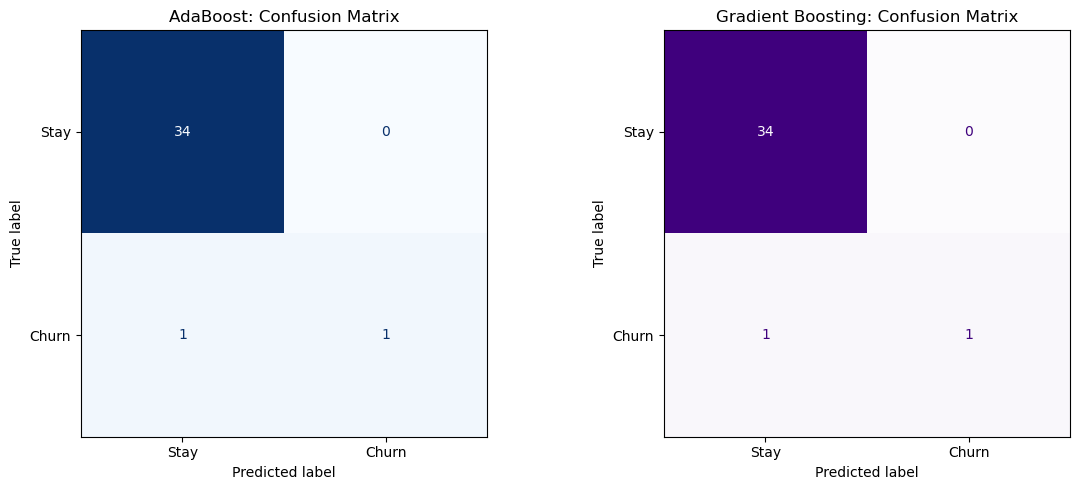

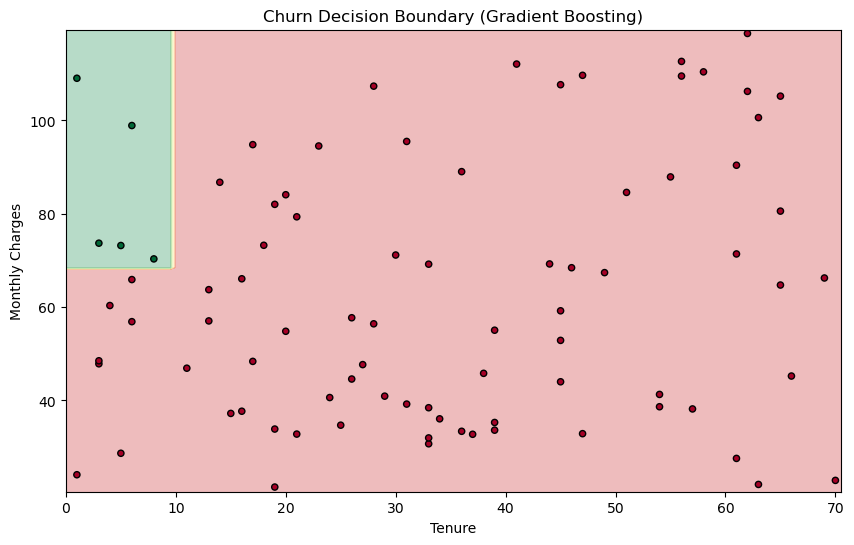

In [10]:
import numpy as np

# --- 6. Enhanced Visualization: Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# AdaBoost Heatmap
cm_ada = confusion_matrix(y_test, y_pred_ada)
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=['Stay', 'Churn'])
disp_ada.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('AdaBoost: Confusion Matrix')

# Gradient Boosting Heatmap
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['Stay', 'Churn'])
disp_gb.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('Gradient Boosting: Confusion Matrix')

plt.tight_layout()
plt.show()

# --- 7. Decision Boundary Visualization (Simplified to 2 Features) ---
# We use the two most common continuous features for the 2D plot
plot_features = ['Tenure', 'MonthlyCharges']
X_plot = X_train[plot_features].values
y_plot = y_train.values

# Re-train a mini-model for visualization purposes only
model_mini = GradientBoostingClassifier(n_estimators=100).fit(X_plot, y_plot)

# Create a mesh grid
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

Z = model_mini.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, s=20, edgecolor='k', cmap='RdYlGn')
plt.xlabel('Tenure')
plt.ylabel('Monthly Charges')
plt.title('Churn Decision Boundary (Gradient Boosting)')
plt.show()